# Pred vs Target Slice Visualization
Visualize sample images/slices from:
- predictions: `data/nnUNet_results/nnunet/{dataset_name}/nnUNetTrainer__nnUNetPlans__2d_tiny16/fold_0/test/{dataset_name}/preds`
- targets: `data/nnUNet_raw/{dataset_name}/labelsTs`
- inputs: `data/nnUNet_raw/{dataset_name}/imagesTs`

In [65]:
from pathlib import Path
import random

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from PIL import Image

from utils import get_dataset_name, get_dataset_json

dataset_id = 505
# cfg = "2d_tiny16"
cfg = "2d"

dataset_name = get_dataset_name(dataset_id)
dataset_json = get_dataset_json(dataset_id)
file_ending = dataset_json['file_ending']

PRED_DIR = Path(f'data/nnUNet_results/nnunet/{dataset_name}/nnUNetTrainer__nnUNetPlans__{cfg}/fold_0/test/{dataset_name}/preds')
RAW_DIR = Path(f'data/nnUNet_raw/{dataset_name}')
IMAGES_TS = RAW_DIR / 'imagesTs'
LABELS_TS = RAW_DIR / 'labelsTs'
TEST_DIR = PRED_DIR.parent.parent
RESULTS_CSV = TEST_DIR / 'results.csv'

def resolve_imagewise_csv(test_dir, dataset_name):
    expected = test_dir / f'image_wise_results_{dataset_name}.csv'
    if expected.exists():
        return expected
    candidates = sorted(test_dir.glob('image_wise_results_*.csv'))
    name_matched = [p for p in candidates if dataset_name in p.name]
    if len(name_matched) == 1:
        return name_matched[0]
    if len(candidates) == 1:
        return candidates[0]
    return expected

IMAGEWISE_CSV = resolve_imagewise_csv(TEST_DIR, dataset_name)

pred_files = sorted([p for p in PRED_DIR.glob(f'*{file_ending}') if p.is_file()])
case_ids = [p.name.replace(file_ending, '') for p in pred_files]

print('pred cases:', len(case_ids))
print('first 10:', case_ids[:10])
if not IMAGEWISE_CSV.exists():
    print(f'warning: image-wise csv not found for dataset {dataset_name}: {IMAGEWISE_CSV}')
    print('available image-wise csv files:', [p.name for p in sorted(TEST_DIR.glob('image_wise_results_*.csv'))])
elif IMAGEWISE_CSV.name != f'image_wise_results_{dataset_name}.csv':
    print(f'warning: using fallback image-wise csv: {IMAGEWISE_CSV.name}')
print('image-wise csv:', IMAGEWISE_CSV)
print('results csv:', RESULTS_CSV)

pred cases: 106
first 10: ['100_IM-0246-0030_anon_a1', '100_IM-0246-0030_anon_a2', '117_IM-0149-0055_anon_a1', '117_IM-0149-0055_anon_a2', '119_IM-0855-0017_anon_a1', '119_IM-0855-0017_anon_a2', '121_IM-0084-0022_anon_a1', '121_IM-0084-0022_anon_a2', '125_IM-0277-0039_anon_a1', '125_IM-0277-0039_anon_a2']
image-wise csv: data/nnUNet_results/nnunet/Dataset505_KidneyUSCapsuleBoth/nnUNetTrainer__nnUNetPlans__2d/fold_0/test/image_wise_results_Dataset505_KidneyUSCapsuleBoth.csv
results csv: data/nnUNet_results/nnunet/Dataset505_KidneyUSCapsuleBoth/nnUNetTrainer__nnUNetPlans__2d/fold_0/test/results.csv


In [66]:
def load_array(path):
    p = str(path)
    if p.endswith('.nii.gz') or p.endswith('.nii'):
        return np.asarray(nib.load(p).get_fdata())
    return np.array(Image.open(path))


def get_input_path(case_id, channel=0):
    requested = IMAGES_TS / f"{case_id}_{channel:04d}{file_ending}"
    if requested.exists():
        return requested
    fallback = IMAGES_TS / f"{case_id}_0000{file_ending}"
    if fallback.exists():
        return fallback
    matches = sorted(IMAGES_TS.glob(f"{case_id}_*{file_ending}"))
    if matches:
        return matches[0]
    return requested


def get_pred_path(case_id):
    return PRED_DIR / f"{case_id}{file_ending}"


def get_label_path(case_id):
    return LABELS_TS / f"{case_id}{file_ending}"


def choose_slice(pred, target):
    # choose slice with largest foreground in target, fallback to prediction
    if pred.ndim != 3:
        return None
    t_fg = (target > 0).sum(axis=(1, 2))
    if np.any(t_fg):
        return int(np.argmax(t_fg))
    p_fg = (pred > 0).sum(axis=(1, 2))
    if np.any(p_fg):
        return int(np.argmax(p_fg))
    return pred.shape[0] // 2


def normalize(img2d):
    x = np.asarray(img2d, dtype=np.float32)
    lo = np.percentile(x, 1)
    hi = np.percentile(x, 99)
    if hi <= lo:
        lo, hi = float(np.min(x)), float(np.max(x))
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    y = (x - lo) / (hi - lo)
    return np.clip(y, 0, 1)


def dice_binary(a, b):
    a = np.asarray(a, dtype=bool)
    b = np.asarray(b, dtype=bool)
    inter = np.logical_and(a, b).sum(dtype=np.float64)
    denom = a.sum(dtype=np.float64) + b.sum(dtype=np.float64)
    if denom == 0:
        return None
    return (2.0 * inter) / denom


def _surface_distances(pred_bin, gt_bin):
    from scipy.ndimage import binary_erosion, distance_transform_edt

    pred_bin = np.asarray(pred_bin, dtype=bool)
    gt_bin = np.asarray(gt_bin, dtype=bool)
    if pred_bin.shape != gt_bin.shape:
        raise ValueError('pred_bin and gt_bin must have the same shape')
    if not np.any(pred_bin) or not np.any(gt_bin):
        return np.array([], dtype=np.float64)

    pred_surface = np.logical_xor(pred_bin, binary_erosion(pred_bin))
    gt_surface = np.logical_xor(gt_bin, binary_erosion(gt_bin))
    if not np.any(pred_surface) or not np.any(gt_surface):
        return np.array([], dtype=np.float64)

    dt_gt = distance_transform_edt(~gt_surface)
    dt_pred = distance_transform_edt(~pred_surface)
    d_pred_to_gt = dt_gt[pred_surface]
    d_gt_to_pred = dt_pred[gt_surface]
    return np.concatenate([d_pred_to_gt, d_gt_to_pred])


def hd95_binary(pred_bin, gt_bin):
    d = _surface_distances(pred_bin, gt_bin)
    if d.size == 0:
        return None
    return float(np.percentile(d, 95))


def get_label_name_map():
    labels = dataset_json.get('labels', {}) if isinstance(dataset_json, dict) else {}
    out = {}
    for name, value in labels.items():
        if isinstance(value, (list, tuple)):
            continue
        out[int(value)] = str(name)
    return out


def multiclass_dice(pred, target, class_ids):
    per_class = {}
    for cid in class_ids:
        d = dice_binary(pred == cid, target == cid)
        per_class[int(cid)] = None if d is None else float(d)
    vals = [v for v in per_class.values() if v is not None]
    macro = float(np.mean(vals)) if vals else None
    return per_class, macro


def multiclass_hd95(pred, target, class_ids):
    per_class = {}
    for cid in class_ids:
        h = hd95_binary(pred == cid, target == cid)
        per_class[int(cid)] = None if h is None else float(h)
    vals = [v for v in per_class.values() if v is not None and np.isfinite(v)]
    macro = float(np.mean(vals)) if vals else None
    return per_class, macro


CLASS_COLORS = [
    '#000000',  # background
    '#90EE90',  # class 1
    '#FFB6C1',  # class 2
    '#87CEEB',  # class 3
    '#FFD700',  # class 4
    '#DDA0DD',  # class 5
]


def class_color_for_id(class_id):
    idx = int(class_id)
    if idx < len(CLASS_COLORS):
        return CLASS_COLORS[idx]
    return CLASS_COLORS[-1]


def build_class_cmap(max_label):
    colors = [class_color_for_id(i) for i in range(int(max_label) + 1)]
    cmap = plt.matplotlib.colors.ListedColormap(colors)
    bounds = np.arange(-0.5, int(max_label) + 1.5, 1)
    norm = plt.matplotlib.colors.BoundaryNorm(bounds, cmap.N)
    return cmap, norm


_IMAGEWISE_METRICS_CACHE = None


def get_imagewise_metrics_map():
    global _IMAGEWISE_METRICS_CACHE
    if _IMAGEWISE_METRICS_CACHE is not None:
        return _IMAGEWISE_METRICS_CACHE
    out = {}
    if not IMAGEWISE_CSV.exists():
        _IMAGEWISE_METRICS_CACHE = out
        return out

    import csv

    with open(IMAGEWISE_CSV, newline='') as f:
        for row in csv.DictReader(f):
            k = row.get('image_id', '')
            dv = row.get('dice', '')
            hv = row.get('hd95', '')
            try:
                d = float(dv)
            except Exception:
                d = None
            try:
                h = float(hv)
            except Exception:
                h = None
            out[k] = {'dice': d, 'hd95': h}

    _IMAGEWISE_METRICS_CACHE = out
    return out


def check_saved_aggregate():
    import csv

    metrics_map = get_imagewise_metrics_map()
    dice_vals = [m.get('dice') for m in metrics_map.values() if m.get('dice') is not None and np.isfinite(m.get('dice'))]
    hd_vals = [m.get('hd95') for m in metrics_map.values() if m.get('hd95') is not None and np.isfinite(m.get('hd95'))]
    if not dice_vals:
        print('No valid dice values found in image-wise CSV.')
        return

    imagewise_mean = float(np.mean(dice_vals))
    imagewise_std = float(np.std(dice_vals))
    print(f'image-wise dice mean/std: {imagewise_mean:.2f} / {imagewise_std:.2f} (n={len(dice_vals)})')
    if hd_vals:
        print(f'image-wise hd95 mean/std: {float(np.mean(hd_vals)):.2f} / {float(np.std(hd_vals)):.2f} (n={len(hd_vals)})')

    if not RESULTS_CSV.exists():
        print(f'results.csv not found: {RESULTS_CSV}')
        return

    rows = []
    with open(RESULTS_CSV, newline='') as f:
        rows = list(csv.DictReader(f))

    class_means = []
    class_hd = []
    for r in rows:
        try:
            class_means.append(float(r.get('dice', 'nan')))
        except Exception:
            pass
        try:
            class_hd.append(float(r.get('hd95', 'nan')))
        except Exception:
            pass

    if class_means:
        print(f'macro of class dice means in results.csv: {float(np.mean(class_means)):.2f}')
    else:
        print('No class-level dice values found in results.csv')
    if class_hd:
        print(f'macro of class hd95 means in results.csv: {float(np.mean(class_hd)):.2f}')


def draw_case(case_id, channel=0, z=None):
    pred = load_array(get_pred_path(case_id)).astype(np.int32)
    target = load_array(get_label_path(case_id)).astype(np.int32)
    inp = load_array(get_input_path(case_id, channel=channel)).astype(np.float32)

    if pred.shape != target.shape:
        raise ValueError(f'shape mismatch pred {pred.shape} vs target {target.shape}')

    if z is None and pred.ndim == 3:
        z = choose_slice(pred, target)

    if pred.ndim == 3:
        pred2d = pred[z]
        target2d = target[z]
        inp2d = inp[z] if inp.ndim == 3 else inp
        title_suffix = f' (z={z})'
    else:
        pred2d = pred
        target2d = target
        inp2d = inp if inp.ndim == 2 else inp[inp.shape[0] // 2]
        title_suffix = ''

    base = normalize(inp2d)
    label_name_map = get_label_name_map()
    configured_fg = sorted([cid for cid in label_name_map.keys() if cid != 0])
    if configured_fg:
        class_ids = configured_fg
    else:
        class_ids = sorted([int(x) for x in np.union1d(np.unique(pred2d), np.unique(target2d)) if int(x) != 0])

    per_class_dice, macro_dice = multiclass_dice(pred2d, target2d, class_ids)
    per_class_hd95, macro_hd95 = multiclass_hd95(pred2d, target2d, class_ids)

    overlay_vmax = int(max(np.max(pred2d), np.max(target2d), 1))
    class_cmap, class_norm = build_class_cmap(overlay_vmax)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{case_id}{title_suffix}', fontsize=12)

    ax[0].imshow(base, cmap='gray')
    ax[0].set_title(f'Input channel {channel}')
    ax[0].axis('off')

    ax[1].imshow(base, cmap='gray')
    ax[1].imshow(np.ma.masked_where(target2d == 0, target2d), cmap=class_cmap, norm=class_norm, alpha=0.45)
    ax[1].set_title('Target overlay')
    ax[1].axis('off')

    ax[2].imshow(base, cmap='gray')
    ax[2].imshow(np.ma.masked_where(pred2d == 0, pred2d), cmap=class_cmap, norm=class_norm, alpha=0.45)
    for cid in class_ids:
        if np.any(target2d == cid):
            ax[2].contour((target2d == cid).astype(float), levels=[0.5], colors=[class_color_for_id(cid)], linewidths=1.5)

    macro_text = '-' if macro_dice is None else f'{100.0 * macro_dice:.2f}%'
    macro_hd_text = '-' if macro_hd95 is None else f'{macro_hd95:.2f}'
    ax[2].set_title(f'Prediction + target contour (Macro Dice={macro_text})')

    csv_metrics = get_imagewise_metrics_map().get(case_id, {})
    csv_dice = csv_metrics.get('dice', None)
    csv_hd95 = csv_metrics.get('hd95', None)
    csv_dice_text = 'n/a' if csv_dice is None else f'{csv_dice:.2f}%'
    csv_hd_text = 'n/a' if csv_hd95 is None else f'{csv_hd95:.2f}'

    dd = None if (macro_dice is None or csv_dice is None) else (100.0 * macro_dice - csv_dice)
    dh = None if (macro_hd95 is None or csv_hd95 is None) else (macro_hd95 - csv_hd95)
    delta_dice_text = 'n/a' if dd is None else f'{dd:+.2f}%'
    delta_hd_text = 'n/a' if dh is None else f'{dh:+.2f}'

    info_text = (
        f'On-fly Dice: {macro_text}\n'
        f'CSV Dice: {csv_dice_text} (Δ {delta_dice_text})\n'
        f'On-fly HD95: {macro_hd_text}\n'
        f'CSV HD95: {csv_hd_text} (Δ {delta_hd_text})'
    )
    ax[2].text(
        0.02,
        0.02,
        info_text,
        transform=ax[2].transAxes,
        fontsize=9,
        color='white',
        bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.3'),
        va='bottom',
        ha='left',
    )
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()

    print(f'macro dice (foreground classes): {macro_text}')
    if csv_dice is None:
        print('image-wise csv dice (volume-level): n/a')
    else:
        print(f'image-wise csv dice (volume-level): {csv_dice:.2f}%')
        if macro_dice is not None:
            print(f'slice-vs-volume dice delta: {100.0 * macro_dice - csv_dice:+.2f}%')

    if csv_hd95 is None:
        print('image-wise csv hd95 (volume-level): n/a')
    else:
        print(f'image-wise csv hd95 (volume-level): {csv_hd95:.2f}')
        if macro_hd95 is not None:
            print(f'slice-vs-volume hd95 delta: {macro_hd95 - csv_hd95:+.2f}')

    for cid in class_ids:
        d = per_class_dice.get(cid)
        d_text = '-' if d is None else f'{100.0 * d:.2f}%'
        h = per_class_hd95.get(cid)
        h_text = '-' if h is None else f'{h:.2f}'
        cname = label_name_map.get(cid, f'class_{cid}')
        print(f'  {cname} ({cid}): Dice={d_text}, HD95={h_text}')

    print('pred labels:', np.unique(pred2d))
    print('target labels:', np.unique(target2d))



sample_ids: ['175_IM-0922-1024_anon_a1', '251_IM-0003-0004_anon_a1', '202_IM-0234-0028_anon_a2', '468_IM-0748-0011_anon_a2', '20_IM-0861-0005_anon_a1', '263_IM-0680-0035_anon_a2', '125_IM-0277-0039_anon_a1', '34_IM-0359-0004-0002_anon_a2']


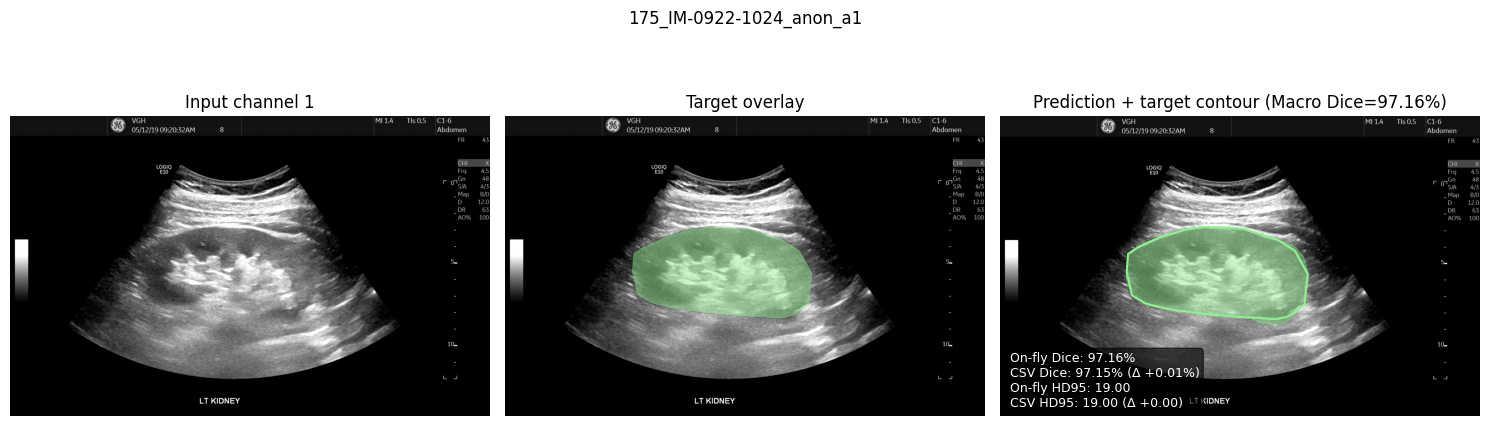

macro dice (foreground classes): 97.16%
image-wise csv dice (volume-level): 97.15%
slice-vs-volume dice delta: +0.01%
image-wise csv hd95 (volume-level): 19.00
slice-vs-volume hd95 delta: +0.00
  Capsule (1): Dice=97.16%, HD95=19.00
pred labels: [0 1]
target labels: [0 1]


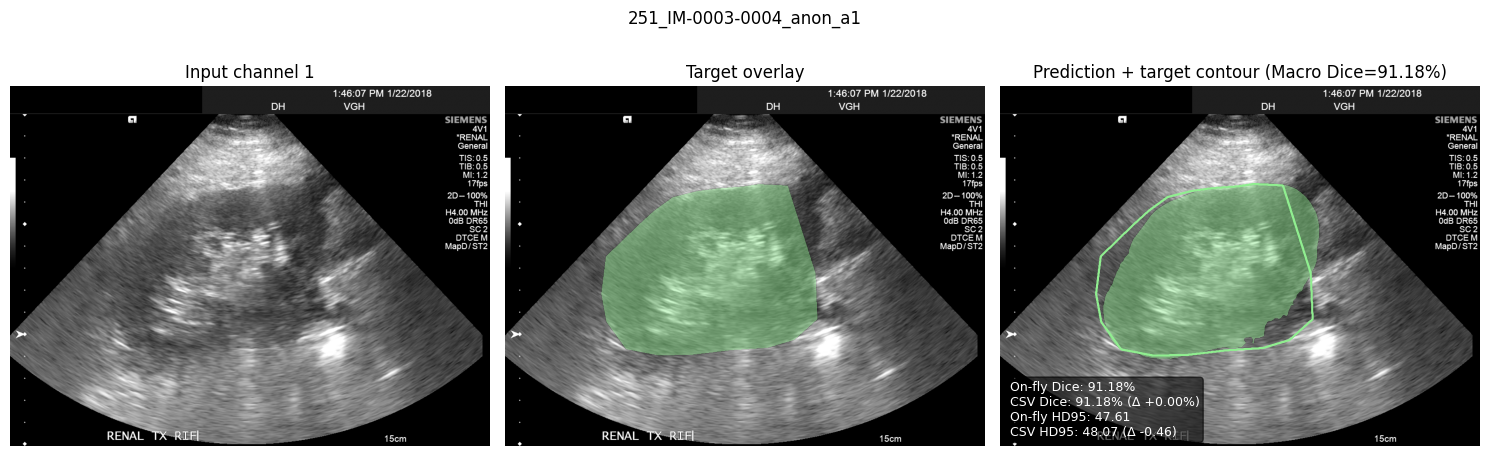

macro dice (foreground classes): 91.18%
image-wise csv dice (volume-level): 91.18%
slice-vs-volume dice delta: +0.00%
image-wise csv hd95 (volume-level): 48.07
slice-vs-volume hd95 delta: -0.46
  Capsule (1): Dice=91.18%, HD95=47.61
pred labels: [0 1]
target labels: [0 1]


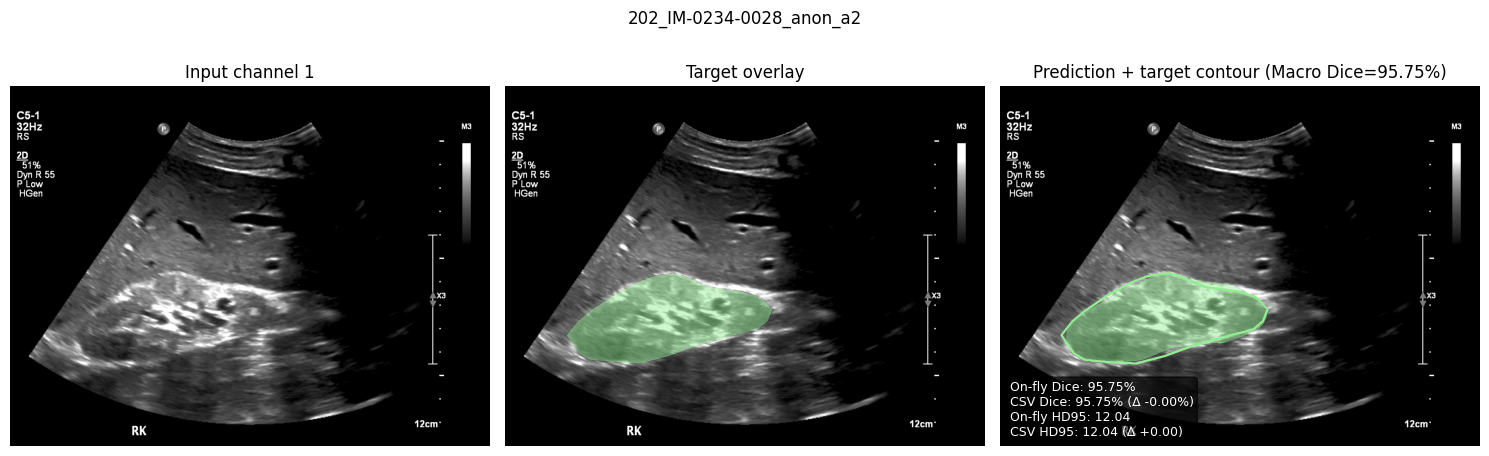

macro dice (foreground classes): 95.75%
image-wise csv dice (volume-level): 95.75%
slice-vs-volume dice delta: -0.00%
image-wise csv hd95 (volume-level): 12.04
slice-vs-volume hd95 delta: +0.00
  Capsule (1): Dice=95.75%, HD95=12.04
pred labels: [0 1]
target labels: [0 1]


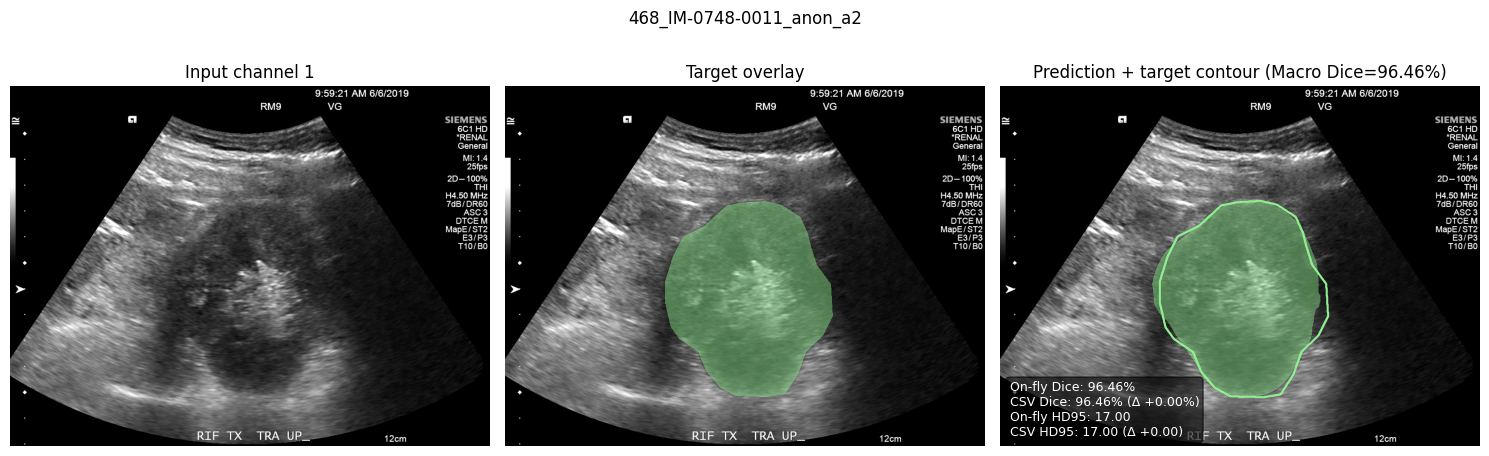

macro dice (foreground classes): 96.46%
image-wise csv dice (volume-level): 96.46%
slice-vs-volume dice delta: +0.00%
image-wise csv hd95 (volume-level): 17.00
slice-vs-volume hd95 delta: +0.00
  Capsule (1): Dice=96.46%, HD95=17.00
pred labels: [0 1]
target labels: [0 1]


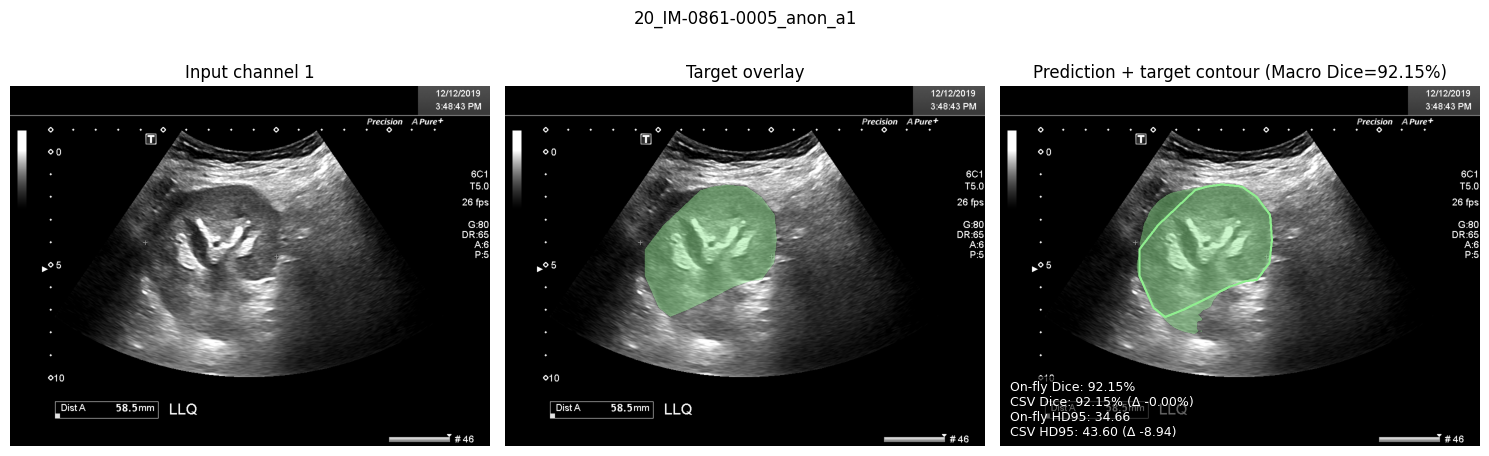

macro dice (foreground classes): 92.15%
image-wise csv dice (volume-level): 92.15%
slice-vs-volume dice delta: -0.00%
image-wise csv hd95 (volume-level): 43.60
slice-vs-volume hd95 delta: -8.94
  Capsule (1): Dice=92.15%, HD95=34.66
pred labels: [0 1]
target labels: [0 1]


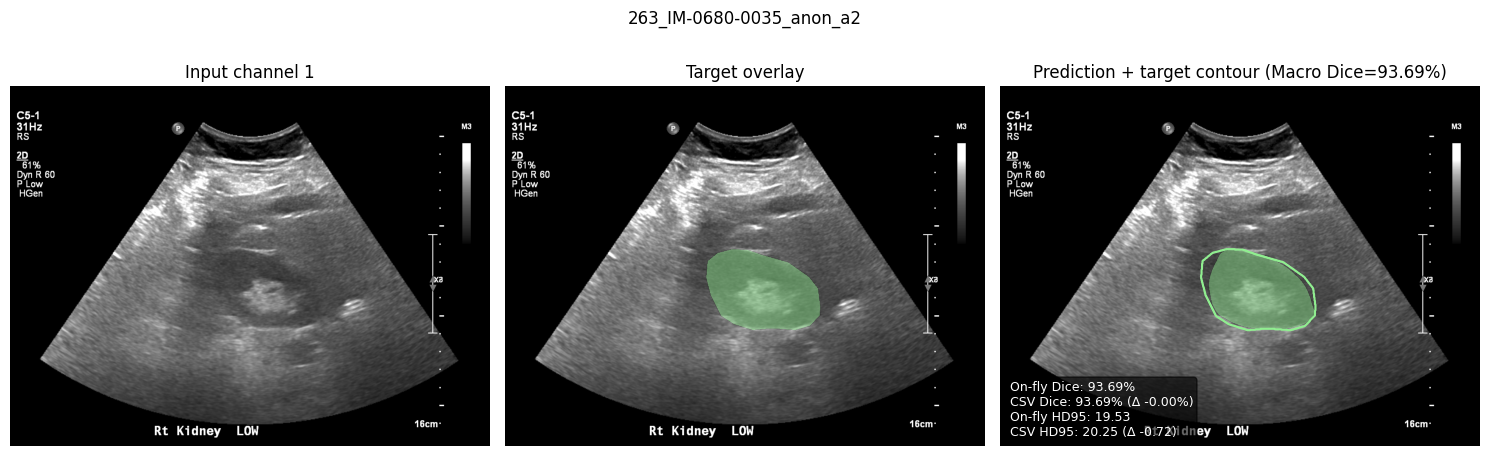

macro dice (foreground classes): 93.69%
image-wise csv dice (volume-level): 93.69%
slice-vs-volume dice delta: -0.00%
image-wise csv hd95 (volume-level): 20.25
slice-vs-volume hd95 delta: -0.72
  Capsule (1): Dice=93.69%, HD95=19.53
pred labels: [0 1]
target labels: [0 1]


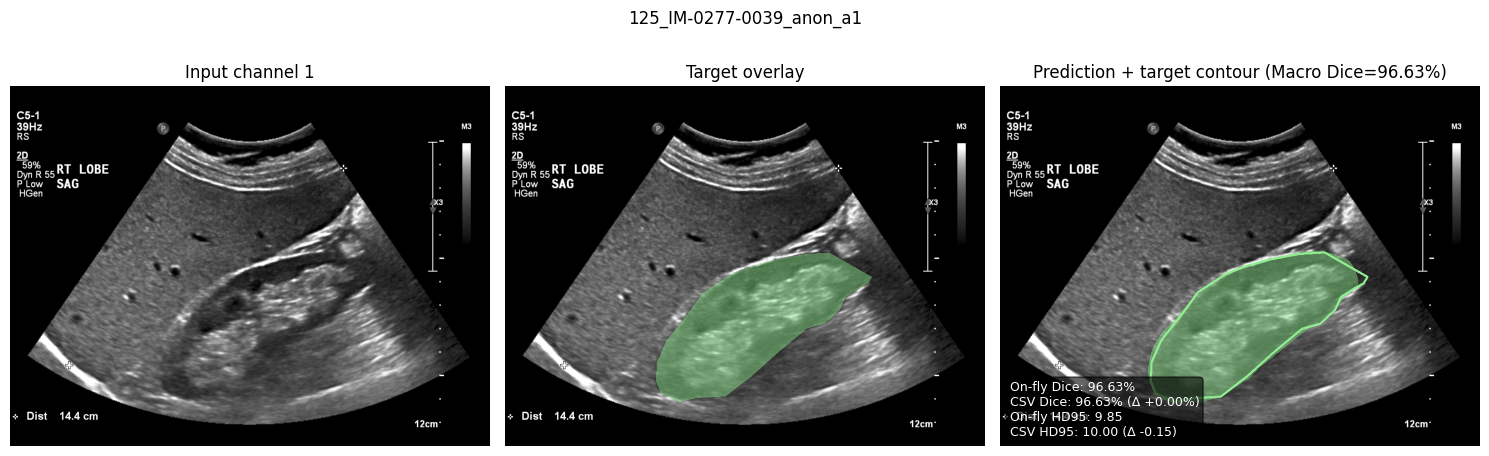

macro dice (foreground classes): 96.63%
image-wise csv dice (volume-level): 96.63%
slice-vs-volume dice delta: +0.00%
image-wise csv hd95 (volume-level): 10.00
slice-vs-volume hd95 delta: -0.15
  Capsule (1): Dice=96.63%, HD95=9.85
pred labels: [0 1]
target labels: [0 1]


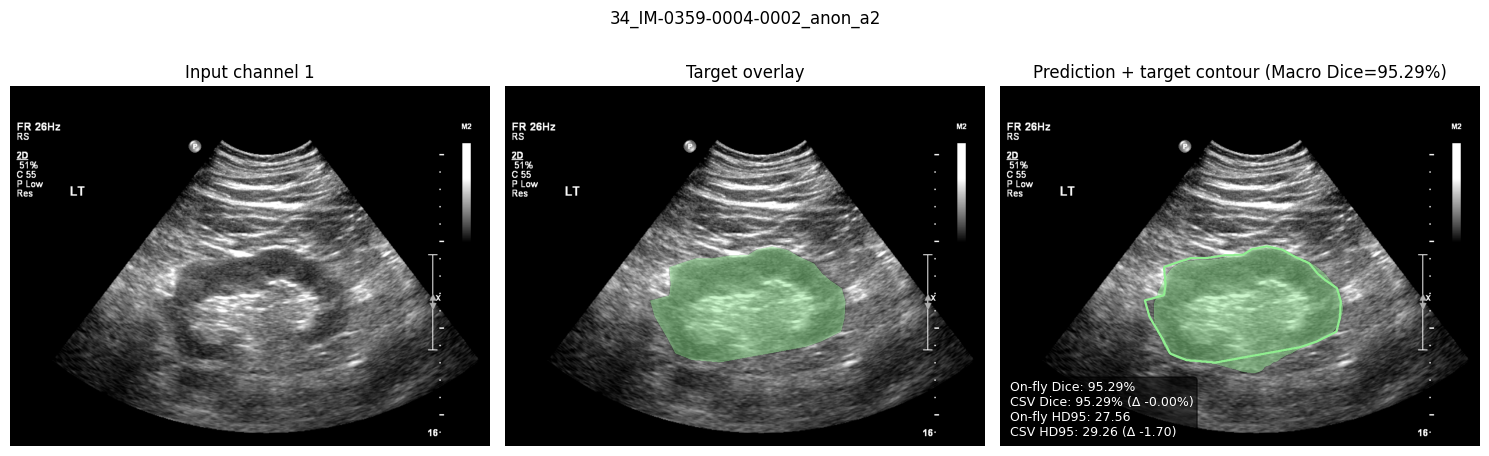

macro dice (foreground classes): 95.29%
image-wise csv dice (volume-level): 95.29%
slice-vs-volume dice delta: -0.00%
image-wise csv hd95 (volume-level): 29.26
slice-vs-volume hd95 delta: -1.70
  Capsule (1): Dice=95.29%, HD95=27.56
pred labels: [0 1]
target labels: [0 1]


In [67]:
# Visualize multiple random cases
num_cases = 8
# seed = 42
channel = 1  # 0:T1, 1:T1ce, 2:T2, 3:Flair

rng = random.Random() #seed)
sample_ids = case_ids if num_cases >= len(case_ids) else rng.sample(case_ids, num_cases)
print('sample_ids:', sample_ids)

for cid in sample_ids:
    draw_case(cid, channel=channel)